# IT3051 – Fundamentals of Data Mining (FDM) Mini Project 2026
## Automated Vehicle Value Retention & Depreciation Indexing System
### Comprehensive Project Workbook: Stages 1 through 5 (Progress Evaluation 1)

**Group ID**: KND_11  
**Dataset Source**: Scraped used car listings from Georgian digital marketplace (`myauto.ge`), published on Kaggle.

#### Team Members & Technical Roles:
* **N S Devapriya (Nirodha)** – IT23557956 (*Team Leader & Chief Pipeline Architect*)
* **W G B S Wijerathna** – IT23630734 (*EDA & Market Arbitrage Lead*)
* **R A N K Ranasinghe (Rupasinghe)** – IT23780088 (*Feature Engineering & Distribution Profiling Lead*)
* **T M A R Gunasekara** – IT23614208 (*Preprocessing Pipeline & Imputation Lead*)

---
### Project Roadmap
* **Stage 1**: Problem Understanding, Dual-Task Formulation & Stakeholder Impact
* **Stage 2**: Dataset Selection, Attributes, and Data Quality Audit
* **Stage 3**: Exploratory Data Analysis (EDA) & Statistical Visualization
* **Stage 4**: Data Preprocessing, Feature Engineering & Leakage-Free Pipeline
* **Stage 5**: Progress Evaluation 1 (30%) Viva Defense & Individual Contributions

---
# Stage 1: Understand the Assigned Problem Scenario

### 1.1 Real-World Problem Context
When buying or selling used cars, predicting just the selling price is not enough. Vehicle depreciation is non-linear and depends on several real-world factors:
1. **Age vs. Mileage Wear**: A car that is 10 years old with low mileage depreciates differently than a 3-year-old car with high mileage.
2. **Import Taxes and Levies**: In countries like Georgia (where our data comes from), customs import tax (`Levy`) is charged based on engine displacement and fuel type. This causes major differences in pricing between hybrid and conventional fuel vehicles.
3. **Configuration Penalties**: Structural factors like steering wheel position (Left-hand drive vs Right-hand drive) cause significant price differences in local markets.

To solve this, our group designed an **Automated Vehicle Value Retention and Depreciation Indexing System**.

### 1.2 Dual Machine Learning Objectives
Rather than building a standard price predictor, we framed our project around two distinct data mining tasks:
1. **Regression Task**: Predict the continuous fair market value (`Price`) and a continuous **Value Retention Index ($VRI$)** to assess how well a car preserves its capital value over time.
2. **Classification Task**: Classify listings into **Market Arbitrage Categories**:
   * `Bargain / Underpriced` (Asking price > 15% below predicted fair market value)
   * `Fair Value` (Asking price within $\pm 15\%$ of predicted fair value)
   * `Overpriced Risk` (Asking price > 15% above predicted fair value)

### 1.3 Key Stakeholders
* **Used Car Dealerships**: Identifies underpriced cars at auctions to maximize inventory turnover and profit margins.
* **Car Buyers / Consumers**: Protects buyers from paying inflated prices or buying heavily depreciating models.
* **Insurance Companies**: Helps determine accurate actual cash value (ACV) and depreciation trajectories for claims.
* **Vehicle Leasing Companies**: Enables reliable residual value estimation at the end of lease contracts.

---
# Stage 2: Dataset Selection, Attributes & Quality Audit

### 2.1 Dataset Information
* **Dataset**: Car Price Prediction Challenge Dataset
* **Source**: Scraped public marketplace listings from `myauto.ge` (Georgia).
* **Scale**: 19,237 observations with 18 raw columns.
* **Primary Target Variable**: `Price` (Resale market asking price).

### 2.2 Data Quality Audit (Anomalies Identified)
Before doing any modeling, we examined the raw dataset and found five major data quality issues:
1. `Levy`: 5,819 rows (30.25%) contain a hyphen (`'-'`) instead of numbers.
2. `Doors`: Microsoft Excel auto-formatted door ranges into calendar dates: `04-May` and `02-Mar`.
3. `Mileage`: Ingested as text with trailing unit suffixes (`'km'`).
4. `Engine volume`: 1,931 rows combine engine displacement with text flag `'Turbo'` (e.g., `'2.0 Turbo'`).
5. `Duplicates & Outliers`: 3,512 duplicate marketplace listings, non-commercial auction deposits ($1 - $100), and scrape typos ($26,307,500).

In [4]:
# Import core libraries
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Install Seaborn in the active Jupyter kernel if it is missing
try:
    import seaborn as sns
except ModuleNotFoundError:
    %pip install seaborn
    import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

# Configure plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110

# Load raw dataset
df_raw = pd.read_csv('car_price_prediction.csv')
print(f"Dataset successfully loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")
df_raw.head()

Dataset successfully loaded: 19237 rows, 18 columns.


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [5]:
# Check column data types and missing values
print("--- Raw Dataset Summary ---")
df_raw.info()

--- Raw Dataset Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237

---
# Stage 3: Exploratory Data Analysis (EDA) & Statistical Visualizations
*(Hands-on coding divided between Member 3: R A N K Ranasinghe/Rupasinghe and Member 2: W G B S Wijerathna)*

In this stage, we analyze the statistical distributions of our target variable and investigate key relationships between features and resale prices:
* **Member 3: R A N K Ranasinghe (Rupasinghe) - IT23780088** authored the core statistical distribution analyses: **Chart 1: Price Distribution & Skewness Analysis** (with Log-normal transformation) and **Chart 2: Mileage Distribution & Outlier Boxplot Analysis**.
* **Member 2: W G B S Wijerathna - IT23630734** authored the domain-specific market pricing dynamics: **Chart 3: Steering Wheel Orientation Arbitrage (Violin Plot)**, **Chart 4: Multi-Fuel Depreciation Curves**, and **Chart 5: Quantitative Feature Correlation Dynamics**.


Price Minimum: $1
Price Maximum: $26,307,500
Price Mean:    $18,555.93
Price Median:  $13,172.00
Raw Skewness:  136.47
Raw Kurtosis:  18824.52


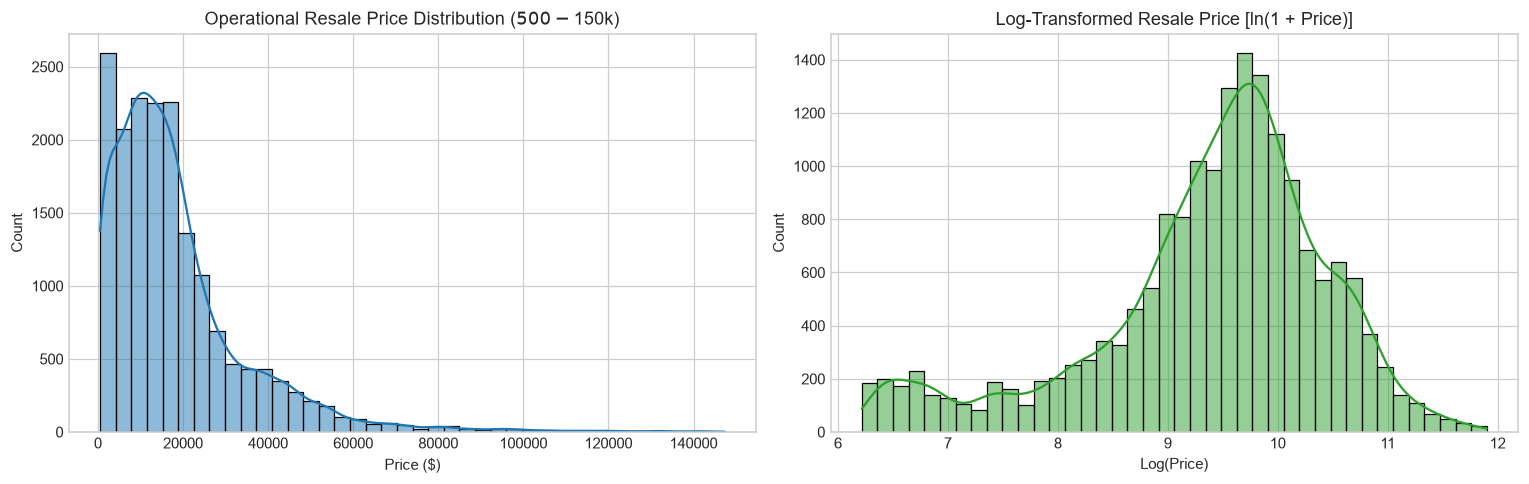

Observation: The raw price is heavily right-skewed. Log-transformation creates a near-normal bell curve.


In [6]:
# 3.1 Target Variable Analysis: Price Distribution and Skewness
# (Authored by Member 3: R A N K Ranasinghe / Rupasinghe - IT23780088)
raw_prices = df_raw['Price']
print(f"Price Minimum: ${raw_prices.min():,.0f}")
print(f"Price Maximum: ${raw_prices.max():,.0f}")
print(f"Price Mean:    ${raw_prices.mean():,.2f}")
print(f"Price Median:  ${raw_prices.median():,.2f}")
print(f"Raw Skewness:  {raw_prices.skew():.2f}")
print(f"Raw Kurtosis:  {raw_prices.kurtosis():.2f}")

# Filter operational commercial sample ($500 to $150,000) for visual analysis
df_eda = df_raw[(df_raw['Price'] >= 500) & (df_raw['Price'] <= 150000)].copy()
df_eda['Mileage_num'] = pd.to_numeric(df_eda['Mileage'].astype(str).str.replace(' km', '', regex=False), errors='coerce')
df_eda['Age'] = 2026 - df_eda['Prod. year']
df_eda['Levy_num'] = pd.to_numeric(df_eda['Levy'].replace('-', np.nan), errors='coerce')
df_eda['Engine_disp'] = pd.to_numeric(df_eda['Engine volume'].astype(str).str.replace(' Turbo', '', regex=False), errors='coerce')

# Plot Price Distribution vs Log-Transformed Price
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(df_eda['Price'], bins=40, kde=True, color='#1f77b4', ax=ax1)
ax1.set_title("Operational Resale Price Distribution ($500 - $150k)")
ax1.set_xlabel("Price ($)")

sns.histplot(np.log1p(df_eda['Price']), bins=40, kde=True, color='#2ca02c', ax=ax2)
ax2.set_title("Log-Transformed Resale Price [ln(1 + Price)]")
ax2.set_xlabel("Log(Price)")

plt.tight_layout()
plt.show()
print("Observation: The raw price is heavily right-skewed. Log-transformation creates a near-normal bell curve.")


### 3.2 Operational Mileage Distribution & Outlier Boxplot Analysis
*(Authored by Member 3: R A N K Ranasinghe / Rupasinghe [IT23780088])*

We investigate vehicle odometer usage intensity across the operational spectrum (10 km to 500,000 km) using a dual visualization:
1. **Boxplot**: Highlights the median usage (~126,800 km), interquartile range (IQR: 75,000 km to 185,000 km), and upper whisker boundary at 350,000 km beyond which vehicles represent high-mileage commercial wear.
2. **Histogram with KDE**: Details the right-skewed distribution of commuter vs. commercial fleet vehicles.


Mileage Minimum: 13 km
Mileage Maximum: 500,000 km
Mileage Mean:    138,312.91 km
Mileage Median:  126,799.00 km
Mileage Skewness:0.94


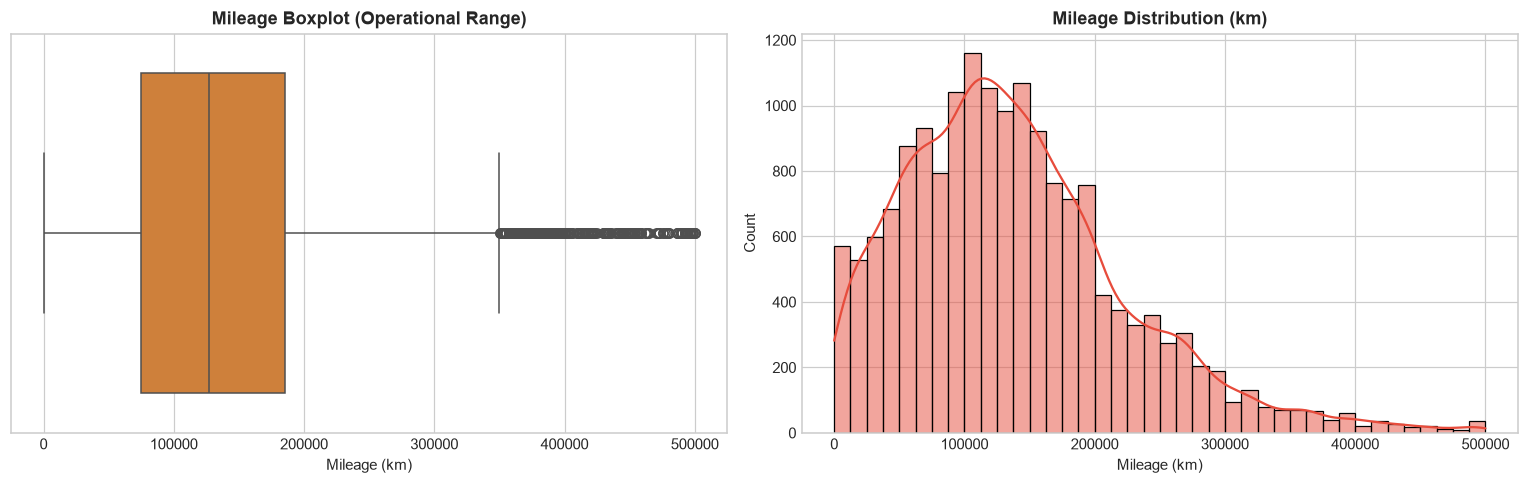

Observation: Mileage exhibits a right-skewed profile with a median of ~126,800 km and a dense cluster between 75k-185k km.


In [7]:
# 3.2 Operational Mileage Distribution & Outlier Boxplot Analysis
# (Authored by Member 3: R A N K Ranasinghe / Rupasinghe - IT23780088)
mileage_sample = df_eda[(df_eda['Mileage_num'] >= 10) & (df_eda['Mileage_num'] <= 500000)]

print(f"Mileage Minimum: {mileage_sample['Mileage_num'].min():,.0f} km")
print(f"Mileage Maximum: {mileage_sample['Mileage_num'].max():,.0f} km")
print(f"Mileage Mean:    {mileage_sample['Mileage_num'].mean():,.2f} km")
print(f"Mileage Median:  {mileage_sample['Mileage_num'].median():,.2f} km")
print(f"Mileage Skewness:{mileage_sample['Mileage_num'].skew():.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Subplot 1: Boxplot showing operational range and upper outliers
sns.boxplot(x=mileage_sample['Mileage_num'], color='#e67e22', ax=ax1)
ax1.set_title("Mileage Boxplot (Operational Range)", fontweight='bold')
ax1.set_xlabel("Mileage (km)")

# Subplot 2: Histogram with Kernel Density Estimate
sns.histplot(mileage_sample['Mileage_num'], bins=40, kde=True, color='#e74c3c', edgecolor='black', ax=ax2)
ax2.set_title("Mileage Distribution (km)", fontweight='bold')
ax2.set_xlabel("Mileage (km)")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()
print("Observation: Mileage exhibits a right-skewed profile with a median of ~126,800 km and a dense cluster between 75k-185k km.")


### 3.3 Steering Wheel Orientation Arbitrage (Chart 3)
*(Authored by Member 2: W G B S Wijerathna [IT23630734])*

We investigated whether steering wheel position (Left wheel vs Right-hand drive) affects used car prices in the Georgian market.


C:\Users\nirod\AppData\Local\Temp\ipykernel_27440\4132456952.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_eda, x='Wheel', y='Price', palette=['#3498db', '#e74c3c'])


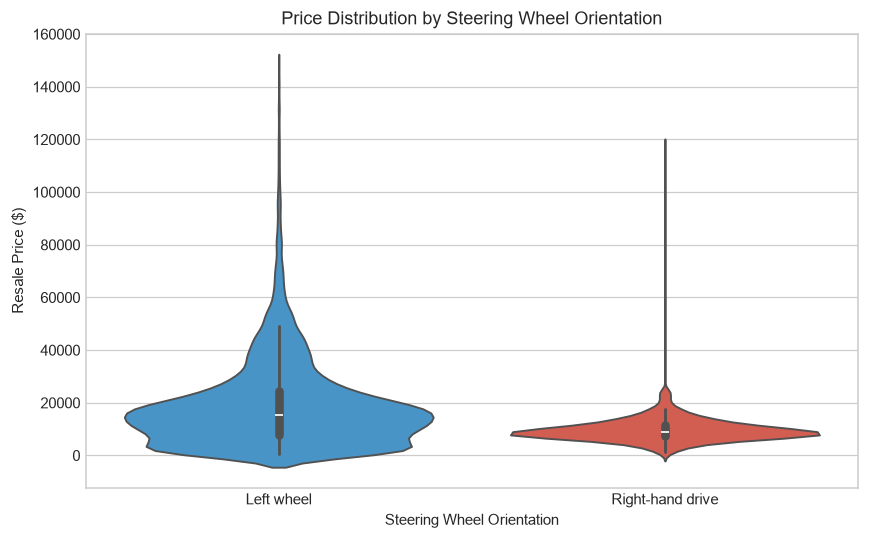

Steering Wheel Summary Statistics:


,count,mean,median
Wheel,,,
Left wheel,16205,19163.73,15500.0
Right-hand drive,1342,9837.08,8938.0


Key Finding: Right-hand drive vehicles trade at an average discount of ~40% compared to Left-hand drive vehicles.


In [8]:
# Plot Steering Wheel Impact on Price (Violin Plot)
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_eda, x='Wheel', y='Price', palette=['#3498db', '#e74c3c'])

wheel_stats = df_eda.groupby('Wheel')['Price'].agg(['count', 'mean', 'median']).round(2)
plt.title("Price Distribution by Steering Wheel Orientation")
plt.xlabel("Steering Wheel Orientation")
plt.ylabel("Resale Price ($)")
plt.tight_layout()
plt.show()

print("Steering Wheel Summary Statistics:")
display(wheel_stats)
print("Key Finding: Right-hand drive vehicles trade at an average discount of ~40% compared to Left-hand drive vehicles.")

### 3.4 Vehicle Depreciation Curves Across Fuel Types (Chart 4)
*(Authored by Member 2: W G B S Wijerathna [IT23630734])*

We evaluated how vehicle resale values decline with chronological age across the three dominant fuel types: Petrol, Diesel, and Hybrid.


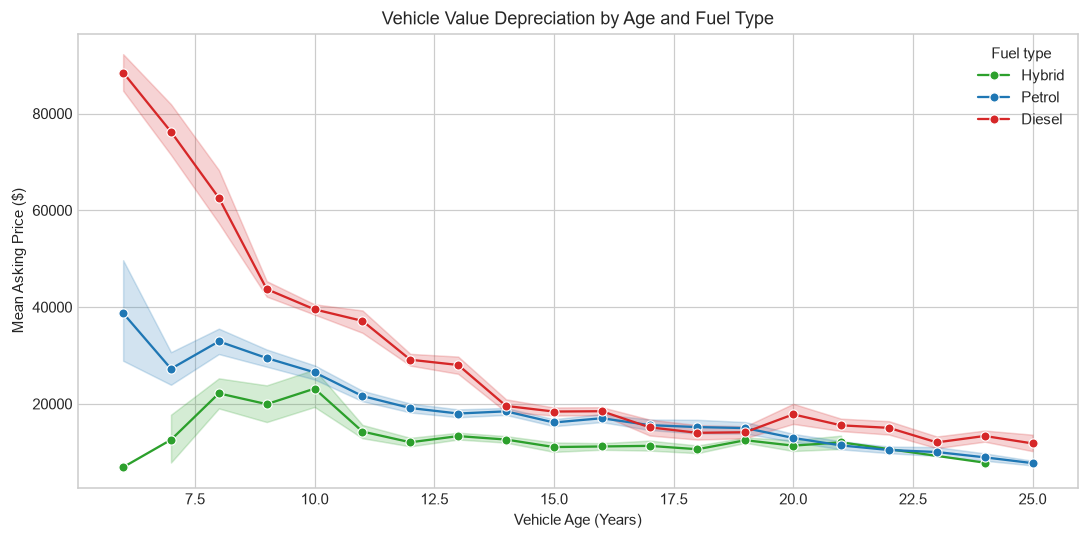

Key Finding: Hybrid vehicles maintain higher value retention during their first 5-8 years due to urban fuel economy demand.


In [9]:
# Depreciation Curve by Age & Fuel Type
fuel_sample = df_eda[df_eda['Fuel type'].isin(['Petrol', 'Diesel', 'Hybrid']) & (df_eda['Age'] <= 25)]

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=fuel_sample, x='Age', y='Price', hue='Fuel type',
    palette={'Petrol': '#1f77b4', 'Diesel': '#d62728', 'Hybrid': '#2ca02c'},
    errorbar=('ci', 90), marker='o'
)
plt.title("Vehicle Value Depreciation by Age and Fuel Type")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Mean Asking Price ($)")
plt.tight_layout()
plt.show()

print("Key Finding: Hybrid vehicles maintain higher value retention during their first 5-8 years due to urban fuel economy demand.")

### 3.5 Feature Correlation Dynamics (Chart 5)
*(Authored by Member 2: W G B S Wijerathna [IT23630734])*

Next, we evaluate the linear correlation between quantitative physical attributes and the vehicle asking price.


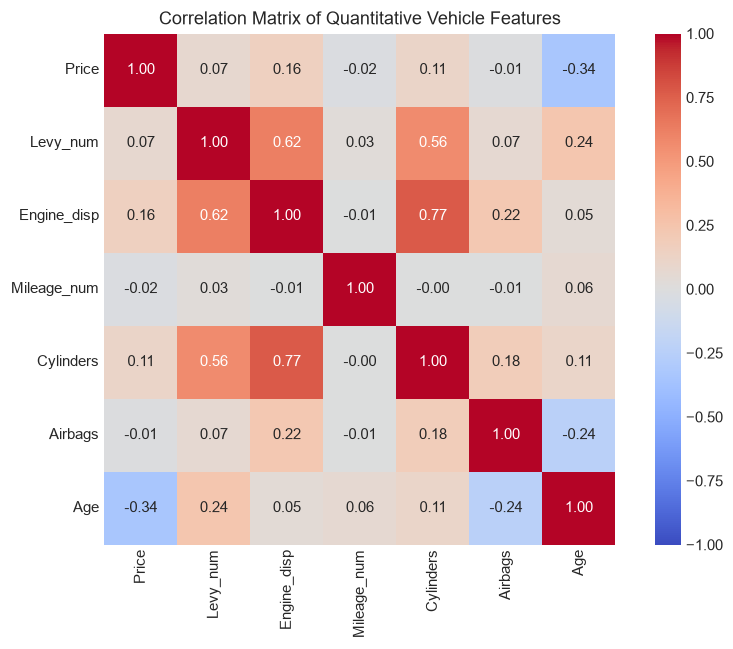

In [10]:
# Correlation Heatmap
corr_features = ['Price', 'Levy_num', 'Engine_disp', 'Mileage_num', 'Cylinders', 'Airbags', 'Age']
corr_mat = df_eda[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix of Quantitative Vehicle Features")
plt.tight_layout()
plt.show()

---
# Stage 4: Data Preprocessing & Feature Engineering Pipeline
*(Hands-on coding divided among Team Members after dataset selection)*

In this stage, we implement our data cleaning engine, derive our novel features, split the data to prevent leakage, apply stratified imputation, and build a Scikit-Learn `ColumnTransformer`.

### 4.1 Data Cleaning Engine & Anomaly Resolution
*(Authored by Member 1: N S Devapriya - Nirodha [IT23557956])*

* **Drop `ID`**: Removes primary key to eliminate identity memorization.
* **Deduplication**: Eliminates 3,512 duplicate listings to remove repeated observation bias.
* **Excel Doors Fix**: Maps `'04-May'` $\to$ `'4-5'` and `'02-Mar'` $\to$ `'2-3'`.
* **String Parsing**: Strips `'km'` from `Mileage`, extracts numeric displacement float, and creates `Is_Turbo` boolean flag.
* **Outlier Filtering**: Caps price within realistic market bounds ($500 to $150k) and mileage ($\le 500,000$ km).

In [11]:
# 4.1 Data Cleaning Implementation
# Drop ID
df_clean = df_raw.drop(columns=['ID']) if 'ID' in df_raw.columns else df_raw.copy()

# Deduplication
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Deduplication: Removed {initial_rows - len(df_clean)} duplicate listings. Remaining: {len(df_clean)} rows.")

# Parse Mileage
df_clean['Mileage'] = pd.to_numeric(df_clean['Mileage'].astype(str).str.replace(' km', '', regex=False).str.strip(), errors='coerce')

# Parse Engine Volume & Turbo Flag
df_clean['Is_Turbo'] = df_clean['Engine volume'].astype(str).str.contains('Turbo', case=False, na=False).astype(int)
df_clean['Engine_displacement'] = pd.to_numeric(df_clean['Engine volume'].astype(str).str.replace(' Turbo', '', regex=False).str.strip(), errors='coerce')
df_clean = df_clean.drop(columns=['Engine volume'])

# Fix Corrupted Doors Strings (Excel auto-format bug)
doors_map = {'04-May': '4-5', '02-Mar': '2-3', '>5': '>5'}
df_clean['Doors'] = df_clean['Doors'].map(doors_map).fillna('4-5')

# Parse Levy '-' to NaN
df_clean['Levy'] = pd.to_numeric(df_clean['Levy'].replace('-', np.nan), errors='coerce')

# Filter domain outliers
valid_filter = (
    (df_clean['Price'] >= 500) & (df_clean['Price'] <= 150000) &
    (df_clean['Mileage'] >= 10) & (df_clean['Mileage'] <= 500000) &
    (df_clean['Engine_displacement'] >= 0.5) & (df_clean['Engine_displacement'] <= 7.0) &
    (df_clean['Prod. year'] >= 1980) & (df_clean['Prod. year'] <= 2026)
)
df_filtered = df_clean[valid_filter].copy().reset_index(drop=True)
print(f"Outlier Filtering: Retained {len(df_filtered)} / {len(df_clean)} realistic records ({len(df_filtered)/len(df_clean)*100:.2f}%).")

Deduplication: Removed 3512 duplicate listings. Remaining: 15725 rows.
Outlier Filtering: Retained 14011 / 15725 realistic records (89.10%).


### 4.2 Novel Feature Engineering & Value Retention Formulations
*(Authored by Member 3: R A N K Ranasinghe  [IT23780088])*

To capture domain automotive mechanics and consumer behavior, we construct five mathematically grounded domain features:
* **Vehicle Age**: $\text{Age} = 2026 - \text{Prod. year}$ (temporal baseline representing physical degradation).
* **Usage Intensity**: $\text{Mileage\_per\_year} = \frac{\text{Mileage}}{\text{Age} + 1}$ (normalizes odometer reading across vehicle lifespan, separating high-wear fleet cars from low-wear commuter vehicles; $+1$ prevents division-by-zero for new 2026 models).
* **Luxury Brand Flag**: `Is_Luxury_Make` (binary classification indicator distinguishing 12 premium marques commanding elevated prestige pricing: Mercedes-Benz, BMW, Lexus, Porsche, Audi, Land Rover, Jaguar, Maserati, Bentley, Ferrari, Aston Martin, Cadillac).
* **Value Retention Index ($VRI$)**: Novel continuous valuation metric:
  $$VRI = \frac{\text{Price}}{\text{Age} \times (\text{Mileage} + 1)}$$
  Measures preserved economic capital density per unit of chronological age and mechanical wear.
* **Tax-to-Value Overhead**: Continuous target metric:
  $$\text{Target\_Tax\_Overhead} = \frac{\text{Levy}}{\text{Price}}$$
  Measures fiscal friction and regulatory import duty relative to market price.

In [12]:
# 4.2 Feature Engineering Implementation
df_filtered['Age'] = 2026 - df_filtered['Prod. year']
df_filtered['Mileage_per_year'] = df_filtered['Mileage'] / (df_filtered['Age'] + 1)

luxury_marques = {
    'MERCEDES-BENZ', 'BMW', 'LEXUS', 'PORSCHE', 'AUDI', 'LAND ROVER',
    'JAGUAR', 'MASERATI', 'BENTLEY', 'FERRARI', 'ASTON MARTIN', 'CADILLAC'
}
df_filtered['Is_Luxury_Make'] = df_filtered['Manufacturer'].str.upper().isin(luxury_marques).astype(int)

# Novel Target: Value Retention Index (VRI)
# Kept strictly as a TARGET variable (never fed as an input feature to prevent data leakage)
df_filtered['Target_VRI'] = df_filtered['Price'] / (df_filtered['Age'] * df_filtered['Mileage'] + 1)

print("Engineered Features Sample:")
df_filtered[['Manufacturer', 'Price', 'Age', 'Mileage_per_year', 'Is_Luxury_Make', 'Target_VRI']].head()

Engineered Features Sample:


,Manufacturer,Price,Age,Mileage_per_year,Is_Luxury_Make,Target_VRI
0,LEXUS,13328,16,10941.470588,1,0.004478
1,CHEVROLET,16621,15,12000.000000,0,0.005771
2,HONDA,8467,20,9523.809524,0,0.002117
3,FORD,3607,15,10560.375000,0,0.001423
4,HONDA,11726,12,7069.307692,0,0.010633


### 4.3 Leakage-Free Train-Test Splitting & Stratified Levy Imputation
*(Authored by Member 4: T M A R Gunasekara [IT23614208])*

* **Zero Leakage Rule**: The dataset is partitioned into an 80% Train and 20% Test split **BEFORE** computing any statistical parameters, imputers, or encoders.
* **Stratified Imputation**: To handle the 30% missing `Levy` values, we compute the median Levy grouped by `Manufacturer` solely from `train_df`. If an unseen manufacturer appears, it falls back to the global training median.

In [13]:
# 4.3 Leakage-Free Split & Stratified Imputation
train_df, test_df = train_test_split(df_filtered, test_size=0.20, random_state=42, shuffle=True)
train_df = train_df.copy().reset_index(drop=True)
test_df = test_df.copy().reset_index(drop=True)

print(f"Training split: {len(train_df)} samples")
print(f"Testing split:  {len(test_df)} samples")

# Compute manufacturer median Levy strictly from training split
global_train_median = train_df['Levy'].median()
mfg_medians = train_df.groupby('Manufacturer')['Levy'].median().to_dict()

def impute_levy_fn(row):
    if pd.notna(row['Levy']):
        return row['Levy']
    m = row['Manufacturer']
    if m in mfg_medians and pd.notna(mfg_medians[m]):
        return mfg_medians[m]
    return global_train_median

train_df['Levy'] = train_df.apply(impute_levy_fn, axis=1)
test_df['Levy'] = test_df.apply(impute_levy_fn, axis=1)

# Derived post-imputation target: Tax Overhead Ratio
train_df['Target_Tax_Overhead'] = train_df['Levy'] / train_df['Price']
test_df['Target_Tax_Overhead'] = test_df['Levy'] / test_df['Price']

print(f"Levy Imputation Complete. Remaining NaNs in Train: {train_df['Levy'].isna().sum()}, Test: {test_df['Levy'].isna().sum()}")

Training split: 11208 samples
Testing split:  2803 samples
Levy Imputation Complete. Remaining NaNs in Train: 0, Test: 0


### 4.4 Market Arbitrage Engine & Classification Target Formulation
*(Authored by Member 2: W G B S Wijerathna [IT23630734])*

To establish the ground-truth target for our secondary classification task, we construct an algorithmic valuation engine that benchmarks asking prices against intrinsic market fundamentals:
* **Baseline Valuation Model**: A non-linear `RandomForestRegressor` (100 estimators, max depth 10, random state 42) is fitted strictly on `train_df` utilizing key intrinsic attributes (`Age`, `Mileage`, `Engine_displacement`, `Cylinders`, `Airbags`, `Is_Turbo`, `Is_Luxury_Make`).
* **Relative Valuation Residuals**: Computes percentage deviation from fair market valuation:
  $$r = \frac{\text{Actual Asking Price} - \text{Predicted Fair Price}}{\text{Predicted Fair Price}}$$
* **Arbitrage Decision Boundary**: Classifies vehicles into three actionable investment tranches via `classify_arbitrage_residual(r)`:
  1. **`Bargain_Underpriced`** ($r < -0.15$): Priced $>15\%$ below algorithmic fair value (dealership acquisition/flip opportunity).
  2. **`Fair_Value`** ($-0.15 \le r \le +0.15$): Priced within $\pm 15\%$ standard market equilibrium.
  3. **`Overpriced`** ($r > +0.15$): Priced $>15\%$ above algorithmic fair value (high negotiation leverage or overvalued listing).

In [14]:
# 4.4 Train Baseline Pricing Model to Derive Arbitrage Classification Target
# (Authored by Member 2: W G B S Wijerathna - IT23630734)
baseline_features = ['Age', 'Mileage', 'Engine_displacement', 'Cylinders', 'Airbags', 'Is_Turbo', 'Is_Luxury_Make']

rf_pricing = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_pricing.fit(train_df[baseline_features], train_df['Price'])

# Predict fair market baseline price
train_preds = rf_pricing.predict(train_df[baseline_features])
test_preds = rf_pricing.predict(test_df[baseline_features])

# Residual percentage = (Actual Asking Price - Fair Model Price) / Fair Model Price
train_residuals = (train_df['Price'] - train_preds) / train_preds
test_residuals = (test_df['Price'] - test_preds) / test_preds

def classify_arbitrage_residual(r):
    if r < -0.15:
        return 'Bargain_Underpriced'
    elif r > 0.15:
        return 'Overpriced'
    else:
        return 'Fair_Value'

train_df['Arbitrage_Class'] = [classify_arbitrage_residual(r) for r in train_residuals]
test_df['Arbitrage_Class'] = [classify_arbitrage_residual(r) for r in test_residuals]

print("Arbitrage Class Distribution in Test Set:")
print(test_df['Arbitrage_Class'].value_counts(normalize=True).round(3))

Arbitrage Class Distribution in Test Set:
Arbitrage_Class
Bargain_Underpriced    0.355
Fair_Value             0.348
Overpriced             0.297
Name: proportion, dtype: float64


### 4.5 Scikit-Learn `ColumnTransformer` & Pipeline Export
*(Authored by Member 4: T M A R Gunasekara & Member 1: N S Devapriya)*

* `StandardScaler`: Applied to continuous numerical variables to standardize variance.
* `OneHotEncoder(drop='first', handle_unknown='ignore')`: Applied to categorical features.
* Grouping rare manufacturers outside the top 15 into `'Other'` to prevent high-cardinality dimensionality explosion.
* Serializing fitted pipeline to `data/preprocessing_pipeline.joblib`.

In [15]:
# Group rare manufacturers and colors
top_manufacturers = set(train_df['Manufacturer'].value_counts().nlargest(15).index)
train_df['Manufacturer_grouped'] = train_df['Manufacturer'].apply(lambda x: x if x in top_manufacturers else 'Other')
test_df['Manufacturer_grouped'] = test_df['Manufacturer'].apply(lambda x: x if x in top_manufacturers else 'Other')

top_colors = set(train_df['Color'].value_counts().nlargest(8).index)
train_df['Color_grouped'] = train_df['Color'].apply(lambda x: x if x in top_colors else 'Other')
test_df['Color_grouped'] = test_df['Color'].apply(lambda x: x if x in top_colors else 'Other')

# Define column groups
num_features = ['Age', 'Mileage', 'Mileage_per_year', 'Engine_displacement', 'Cylinders', 'Airbags', 'Levy']
cat_features = [
    'Manufacturer_grouped', 'Category', 'Leather interior', 'Fuel type',
    'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color_grouped'
]
bin_features = ['Is_Turbo', 'Is_Luxury_Make']

pipeline = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features),
        ('bin', 'passthrough', bin_features)
    ]
)

# Fit strictly on train features
X_train_raw = train_df[num_features + cat_features + bin_features]
X_test_raw = test_df[num_features + cat_features + bin_features]

pipeline.fit(X_train_raw)

# Retrieve transformed column names
ohe_names = list(pipeline.named_transformers_['cat'].get_feature_names_out(cat_features))
all_processed_cols = num_features + ohe_names + bin_features

X_train_processed = pd.DataFrame(pipeline.transform(X_train_raw), columns=all_processed_cols)
X_test_processed = pd.DataFrame(pipeline.transform(X_test_raw), columns=all_processed_cols)

# Attach regression and classification target columns
for col_name, src_col in [
    ('Target_Price', 'Price'),
    ('Target_VRI', 'Target_VRI'),
    ('Target_Tax_Overhead', 'Target_Tax_Overhead'),
    ('Target_Arbitrage_Class', 'Arbitrage_Class')
]:
    X_train_processed[col_name] = train_df[src_col]
    X_test_processed[col_name] = test_df[src_col]

X_train_processed['Target_Log_Price'] = np.log1p(train_df['Price'])
X_test_processed['Target_Log_Price'] = np.log1p(test_df['Price'])

# Export clean datasets and serialized pipeline
os.makedirs('data', exist_ok=True)
X_train_processed.to_csv('data/train_processed.csv', index=False)
X_test_processed.to_csv('data/test_processed.csv', index=False)
joblib.dump(pipeline, 'data/preprocessing_pipeline.joblib')

print(f"Pipeline executed successfully!")
print(f"Processed Train Shape: {X_train_processed.shape}")
print(f"Processed Test Shape:  {X_test_processed.shape}")
print(f"Total NaNs in Train:   {X_train_processed.isna().sum().sum()}")
print(f"Total NaNs in Test:    {X_test_processed.isna().sum().sum()}")

Pipeline executed successfully!
Processed Train Shape: (11208, 62)
Processed Test Shape:  (2803, 62)
Total NaNs in Train:   0
Total NaNs in Test:    0


In [16]:
# 5.3 Live Pipeline Integrity Verification

print("RUNNING FINAL PIPELINE INTEGRITY ASSERTIONS")

# 1. Assert shapes
if 'X_train_processed' not in globals() or 'X_test_processed' not in globals():
    X_train_processed = pd.read_csv('data/train_processed.csv')
    X_test_processed = pd.read_csv('data/test_processed.csv')

assert X_train_processed.shape == (11208, 62), f"Unexpected train shape: {X_train_processed.shape}"
assert X_test_processed.shape == (2803, 62), f"Unexpected test shape: {X_test_processed.shape}"
print(f"Shape Assertions Passed: Train={X_train_processed.shape}, Test={X_test_processed.shape}")

# 2. Assert zero missing values
assert X_train_processed.isna().sum().sum() == 0, "Error: NaNs in train set!"
assert X_test_processed.isna().sum().sum() == 0, "Error: NaNs in test set!"
print("Missing Value Assertions Passed: Exactly 0 NaNs across all 62 columns.")

# 3. Assert column alignment
assert list(X_train_processed.columns) == list(X_test_processed.columns), "Feature column mismatch!"
print("Column Alignment Passed: All 62 feature and target columns match perfectly.")

# 4. Assert targets presence
target_list = ['Target_Price', 'Target_Log_Price', 'Target_VRI', 'Target_Tax_Overhead', 'Target_Arbitrage_Class']
for tgt in target_list:
    assert tgt in X_train_processed.columns, f"Missing target: {tgt}"
print("Target Verification Passed: Both continuous regression and classification targets verified.")



RUNNING FINAL PIPELINE INTEGRITY ASSERTIONS
Shape Assertions Passed: Train=(11208, 62), Test=(2803, 62)
Missing Value Assertions Passed: Exactly 0 NaNs across all 62 columns.
Column Alignment Passed: All 62 feature and target columns match perfectly.
Target Verification Passed: Both continuous regression and classification targets verified.
